# SKA-Low conversion guide

In [1]:
from importlib.metadata import version
import os

try:
    import xradio

    print("XRADIO version", version("xradio"), "already installed.")
except ImportError as e:
    print(e)
    print("Installing XRADIO")

    os.system("pip install xradio")

    import xradio

    print("xradio version", version("xradio"), " installed.")

XRADIO version 1.1.3 already installed.


## Download Dataset

In [2]:
import toolviper

toolviper.utils.data.download(file="ska_low_sim_18s.ms")

[2026-04-20 15:19:58,240]     INFO   toolviper:  Initializing download... 
[2026-04-20 15:19:58,241]     INFO   toolviper:  File already exists: /Users/vdesouza/work/xradio/docs/source/measurement_set/guides/ska_low_sim_18s.ms 


## Convert to Processing Set

In [3]:
from xradio.measurement_set import convert_msv2_to_processing_set

ms_file = "ska_low_sim_18s.ms"
outfile = "ska_low_sim_18s.ps.zarr"
convert_msv2_to_processing_set(
    in_file=ms_file,
    out_file=outfile,
    parallel_mode="none",
    persistence_mode='w',
)

[2026-04-20 15:19:58,528]     INFO   toolviper:  Updated partition scheme used: ['DATA_DESC_ID', 'OBS_MODE', 'OBSERVATION_ID'] 
[2026-04-20 15:19:58,529]     INFO   toolviper:  Number of partitions: 1 
[2026-04-20 15:19:58,529]     INFO   toolviper:  OBSERVATION_ID [0], DDI [0], STATE [0], FIELD [0], SCAN [0], EPHEMERIS [None] 
[2026-04-20 15:19:58,580]  WARNING   toolviper:  SOURCE table empty for (unique) source_id [0] and spectral_window_id 0. 


## Processing Set

In [4]:
ps_name = outfile

from xradio.measurement_set import open_processing_set

ps_xdt = open_processing_set(ps_store=outfile)
ps_xdt.xr_ps.summary()

,name,scan_intents,shape,execution_block_UID,polarization,scan_name,spw_name,spw_intents,field_name,source_name,line_name,field_coords,session_reference_UID,scheduling_block_UID,project_UID,start_frequency,end_frequency
0,ska_low_sim_18s_0,[OBSERVE_TARGET#ON_SOURCE],"(67, 153, 27, 4)",---,"[XX, XY, YX, YY]",[0],spw_0,[UNSPECIFIED],[_0],[Unknown],[],"[fk5, 11h20m00.00s, -10d00m00.00s]",---,---,,1.013862e+08,1.736084e+08


In [5]:
ps_xdt["ska_low_sim_18s_0"]

<xarray.DataTree 'ska_low_sim_18s_0'>
Group: /ska_low_sim_18s_0
│   Dimensions:                     (time: 67, baseline_id: 153, frequency: 27,
│                                    polarization: 4, uvw_label: 3)
│   Coordinates:
│     * time                        (time) float64 536B 9.47e+08 ... 9.47e+08
│       field_name                  (time) <U23 6kB dask.array<chunksize=(67,), meta=np.ndarray>
│       scan_name                   (time) <U21 6kB dask.array<chunksize=(67,), meta=np.ndarray>
│     * baseline_id                 (baseline_id) int64 1kB 0 1 2 3 ... 150 151 152
│       baseline_antenna1_name      (baseline_id) <U24 15kB dask.array<chunksize=(153,), meta=np.ndarray>
│       baseline_antenna2_name      (baseline_id) <U24 15kB dask.array<chunksize=(153,), meta=np.ndarray>
│     * frequency                   (frequency) float64 216B 1.014e+08 ... 1.736e+08
│     * polarization                (polarization) <U2 32B 'XX' 'XY' 'YX' 'YY'
│     * uvw_label                   (uvw_label) <U1 12B 'u' 'v' 'w'
│   Data variables:
│       EFFECTIVE_INTEGRATION_TIME  (time, baseline_id) float64 82kB dask.array<chunksize=(67, 153), meta=np.ndarray>
│       FLAG                        (time, baseline_id, frequency, polarization) bool 1MB dask.array<chunksize=(67, 153, 27, 4), meta=np.ndarray>
│       TIME_CENTROID               (time, baseline_id) float64 82kB dask.array<chunksize=(67, 153), meta=np.ndarray>
│       UVW                         (time, baseline_id, uvw_label) float64 246kB dask.array<chunksize=(67, 153, 3), meta=np.ndarray>
│       VISIBILITY                  (time, baseline_id, frequency, polarization) complex64 9MB dask.array<chunksize=(67, 153, 27, 4), meta=np.ndarray>
│       WEIGHT                      (time, baseline_id, frequency, polarization) float32 4MB dask.array<chunksize=(67, 153, 27, 4), meta=np.ndarray>
│   Attributes:
│       creation_date:     2026-04-20T21:19:58.537824+00:00
│       creator:           {'software_name': 'xradio', 'version': '1.1.3'}
│       data_groups:       {'base': {'correlated_data': 'VISIBILITY', 'date': '20...
│       observation_info:  {'observer': ['fd382'], 'observing_log': "['']", 'proj...
│       processor_info:    {'sub_type': '', 'type': ''}
│       schema_version:    4.0.0
│       type:              visibility
├── Group: /ska_low_sim_18s_0/antenna_xds
│       Dimensions:                 (antenna_name: 18, cartesian_pos_label: 3,
│                                    receptor_label: 2)
│       Coordinates:
│         * antenna_name            (antenna_name) <U24 2kB 's0000 (station345_S8-1)'...
│           mount                   (antenna_name) <U5 360B dask.array<chunksize=(18,), meta=np.ndarray>
│           station_name            (antenna_name) <U5 360B dask.array<chunksize=(18,), meta=np.ndarray>
│           telescope_name          (antenna_name) <U12 864B dask.array<chunksize=(18,), meta=np.ndarray>
│         * cartesian_pos_label     (cartesian_pos_label) <U1 12B 'x' 'y' 'z'
│         * receptor_label          (receptor_label) <U5 40B 'pol_0' 'pol_1'
│           polarization_type       (antenna_name, receptor_label) <U1 144B dask.array<chunksize=(18, 2), meta=np.ndarray>
│       Data variables:
│           ANTENNA_DISH_DIAMETER   (antenna_name) float64 144B dask.array<chunksize=(18,), meta=np.ndarray>
│           ANTENNA_POSITION        (antenna_name, cartesian_pos_label) float64 432B dask.array<chunksize=(18, 3), meta=np.ndarray>
│           ANTENNA_RECEPTOR_ANGLE  (antenna_name, receptor_label) float64 288B dask.array<chunksize=(18, 2), meta=np.ndarray>
│       Attributes:
│           overall_telescope_name:  OSKAR 2.10.0
│           relocatable_antennas:    False
│           type:                    antenna
├── Group: /ska_low_sim_18s_0/field_and_source_base_xds
│       Dimensions:                       (field_name: 1, sky_dir_label: 2)
│       Coordinates:
│         * field_name                    (field_name) <U23 92B '_0'
│           source_name            

In [6]:
msv4_xdt = ps_xdt["ska_low_sim_18s_0"]
msv4_xdt.ds

<xarray.DatasetView> Size: 15MB
Dimensions:                     (time: 67, baseline_id: 153, frequency: 27,
                                 polarization: 4, uvw_label: 3)
Coordinates:
  * time                        (time) float64 536B 9.47e+08 ... 9.47e+08
    field_name                  (time) <U23 6kB dask.array<chunksize=(67,), meta=np.ndarray>
    scan_name                   (time) <U21 6kB dask.array<chunksize=(67,), meta=np.ndarray>
  * baseline_id                 (baseline_id) int64 1kB 0 1 2 3 ... 150 151 152
    baseline_antenna1_name      (baseline_id) <U24 15kB dask.array<chunksize=(153,), meta=np.ndarray>
    baseline_antenna2_name      (baseline_id) <U24 15kB dask.array<chunksize=(153,), meta=np.ndarray>
  * frequency                   (frequency) float64 216B 1.014e+08 ... 1.736e+08
  * polarization                (polarization) <U2 32B 'XX' 'XY' 'YX' 'YY'
  * uvw_label                   (uvw_label) <U1 12B 'u' 'v' 'w'
Data variables:
    EFFECTIVE_INTEGRATION_TIME  (time, baseline_id) float64 82kB dask.array<chunksize=(67, 153), meta=np.ndarray>
    FLAG                        (time, baseline_id, frequency, polarization) bool 1MB dask.array<chunksize=(67, 153, 27, 4), meta=np.ndarray>
    TIME_CENTROID               (time, baseline_id) float64 82kB dask.array<chunksize=(67, 153), meta=np.ndarray>
    UVW                         (time, baseline_id, uvw_label) float64 246kB dask.array<chunksize=(67, 153, 3), meta=np.ndarray>
    VISIBILITY                  (time, baseline_id, frequency, polarization) complex64 9MB dask.array<chunksize=(67, 153, 27, 4), meta=np.ndarray>
    WEIGHT                      (time, baseline_id, frequency, polarization) float32 4MB dask.array<chunksize=(67, 153, 27, 4), meta=np.ndarray>
Attributes:
    creation_date:     2026-04-20T21:19:58.537824+00:00
    creator:           {'software_name': 'xradio', 'version': '1.1.3'}
    data_groups:       {'base': {'correlated_data': 'VISIBILITY', 'date': '20...
    observation_info:  {'observer': ['fd382'], 'observing_log': "['']", 'proj...
    processor_info:    {'sub_type': '', 'type': ''}
    schema_version:    4.0.0
    type:              visibility

In [7]:
ant_xds = ps_xdt.xr_ps.get_combined_antenna_xds()
ant_xds

<xarray.Dataset> Size: 6kB
Dimensions:                 (antenna_name: 18, cartesian_pos_label: 3,
                             receptor_label: 2, baseline_id: 153,
                             frequency: 27, polarization: 4, time: 67,
                             uvw_label: 3)
Coordinates:
  * antenna_name            (antenna_name) <U24 2kB 's0000 (station345_S8-1)'...
    mount                   (antenna_name) <U5 360B dask.array<chunksize=(18,), meta=np.ndarray>
    station_name            (antenna_name) <U5 360B dask.array<chunksize=(18,), meta=np.ndarray>
    telescope_name          (antenna_name) <U12 864B dask.array<chunksize=(18,), meta=np.ndarray>
  * cartesian_pos_label     (cartesian_pos_label) <U1 12B 'x' 'y' 'z'
  * receptor_label          (receptor_label) <U5 40B 'pol_0' 'pol_1'
    polarization_type       (antenna_name, receptor_label) <U1 144B dask.array<chunksize=(18, 2), meta=np.ndarray>
  * baseline_id             (baseline_id) int64 1kB 0 1 2 3 ... 149 150 151 152
  * frequency               (frequency) float64 216B 1.014e+08 ... 1.736e+08
  * polarization            (polarization) <U2 32B 'XX' 'XY' 'YX' 'YY'
  * time                    (time) float64 536B 9.47e+08 9.47e+08 ... 9.47e+08
  * uvw_label               (uvw_label) <U1 12B 'u' 'v' 'w'
Data variables:
    ANTENNA_DISH_DIAMETER   (antenna_name) float64 144B dask.array<chunksize=(18,), meta=np.ndarray>
    ANTENNA_POSITION        (antenna_name, cartesian_pos_label) float64 432B dask.array<chunksize=(18, 3), meta=np.ndarray>
    ANTENNA_RECEPTOR_ANGLE  (antenna_name, receptor_label) float64 288B dask.array<chunksize=(18, 2), meta=np.ndarray>
Attributes:
    overall_telescope_name:  OSKAR 2.10.0
    relocatable_antennas:    False
    type:                    antenna

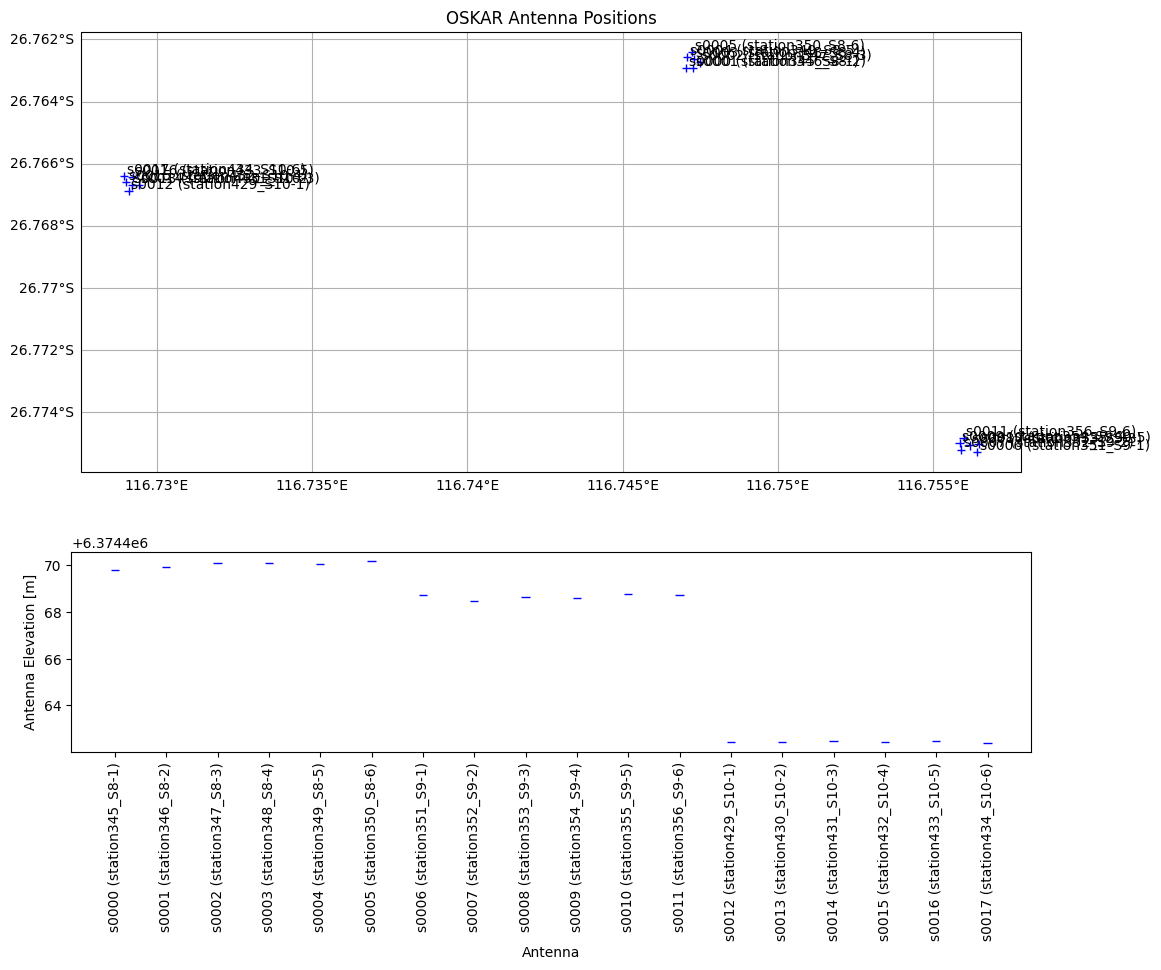

In [8]:
ps_xdt.xr_ps.plot_antenna_positions_2d()